<a href="https://colab.research.google.com/github/eduardofmj97/EBAC/blob/main/Profissao_Cientista_de_Dados_M15_Pratique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [4]:
df = pd.read_csv("/content/drive/MyDrive/dados_processados.csv", delimiter=',')

df.head(10)

,customerID,gender,elderly,married,dependents,tenure_months,internet_service,online_security,tech_support,streaming_tv,contract_type,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,F,0,Yes,No,1,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,M,0,No,No,34,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,M,0,No,No,2,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,M,0,No,No,45,DSL,Yes,Yes,No,One year,Bank transfer (automatic),71.45,1840.75,No
4,8191-XWSZG,F,0,No,No,52,No,No internet service,No internet service,No internet service,One year,Mailed check,71.45,1022.95,No
5,9959-WOFKT,M,0,No,Yes,71,Fiber optic,Yes,No,Yes,Two year,Bank transfer (automatic),71.45,7382.25,No
6,4190-MFLUW,F,0,Yes,Yes,10,DSL,No,Yes,No,Month-to-month,Credit card (automatic),71.45,528.35,Yes
7,4183-MYFRB,F,0,No,No,21,Fiber optic,No,No,No,Month-to-month,Electronic check,71.45,1862.90,No
8,8779-QRDMV,M,1,No,No,1,DSL,No,No,No,Month-to-month,Electronic check,71.45,39.65,Yes
9,1680-VDCWW,M,0,Yes,No,12,No,No internet service,No internet service,No internet service,One year,Bank transfer (automatic),71.45,202.25,No


# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

In [5]:
df.describe(include='all')

,customerID,gender,elderly,married,dependents,tenure_months,internet_service,online_security,tech_support,streaming_tv,contract_type,payment_method,monthly_charges,total_charges,churn
count,2488,2488,2488.000000,2488,2488,2488.000000,2488,2488,2488,2488,2488,2488,2488.000000,2488.000000,2488
unique,2488,2,NaN,2,2,NaN,3,3,3,3,3,4,NaN,NaN,2
top,6061-GWWAV,M,NaN,No,No,NaN,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,NaN,No
freq,1,1269,NaN,1262,1705,NaN,1119,1254,1250,1001,1369,830,NaN,NaN,1841
mean,NaN,NaN,0.161576,NaN,NaN,32.352090,NaN,NaN,NaN,NaN,NaN,NaN,66.342564,2290.087178,NaN
std,NaN,NaN,0.368135,NaN,NaN,24.636885,NaN,NaN,NaN,NaN,NaN,NaN,28.051718,2264.585643,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,18.400000,18.800000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,NaN,NaN,45.400000,402.337500,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,71.450000,1402.900000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,56.000000,NaN,NaN,NaN,NaN,NaN,NaN,87.712500,3867.162500,NaN


Nessa análise, podemos identificar que possivelmente há outliers na variável "total_charges", uma vez que temos um mínimo de 18, sendo um valor baixo em relação ao primeiro quartil (possivelmente caracterizando novos clientes), e um máximo de 8564 (possivelmente caracterizando clientes muito antigos), sendo um valor maior do que o dobro do terceiro quartil.
Nesse caso, inferir que há outliers pode ser algo errado, uma vez que o comportamento esperado dessa variável é que haja um valor acumulativo ao longo dos meses em que os clientes não dão churn, demonstrando uma estrutura de negócio efetiva nesses casos, e não a presença de outliers.

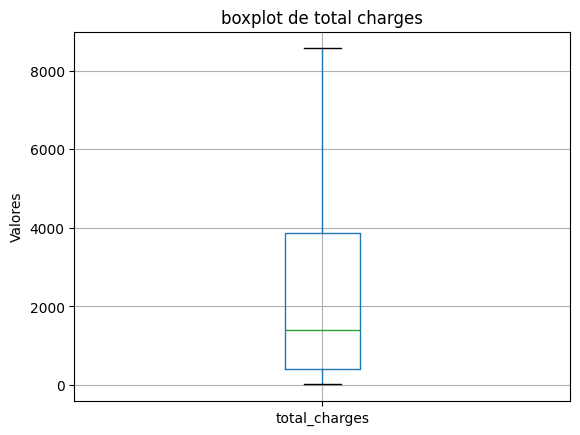

In [6]:
df.boxplot(column='total_charges')
plt.title('boxplot de total charges')
plt.ylabel('Valores')
plt.show()

Outro erro estatístico que podemos notar é relacionado a variável 'elderly', onde o IQR é igual a 0, fazendo com que todos os valores iguais a 1 aparentemente se tornem outliers. Isso é um falso positivo estatístico, então não podemos considerar como outlier, como podemos ver no seguinte gráfico:

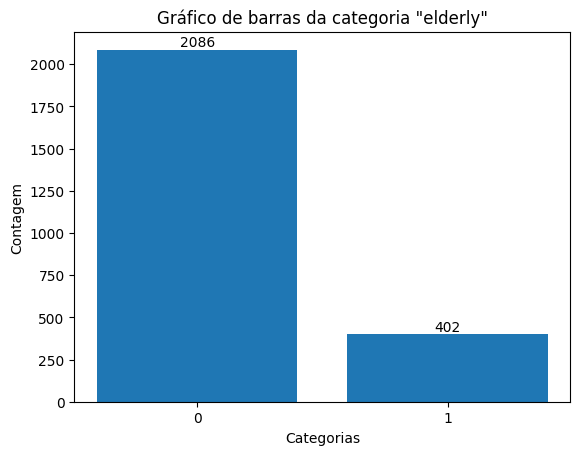

In [7]:
elderly_counts = df['elderly'].value_counts()
plt.bar(elderly_counts.index, elderly_counts.values)
plt.xlabel('Categorias')
plt.ylabel('Contagem')
plt.title('Gráfico de barras da categoria "elderly"')
plt.xticks([0, 1])
for index, value in elderly_counts.items():
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()

Podemos notar que há uma grande variação entre idosos e não idosos nos dados onde o primeiro grupo contém somente 402 indivíduos, já o segundo, 2086, ou seja, os idosos compõem somente  16,16% dos clientes.

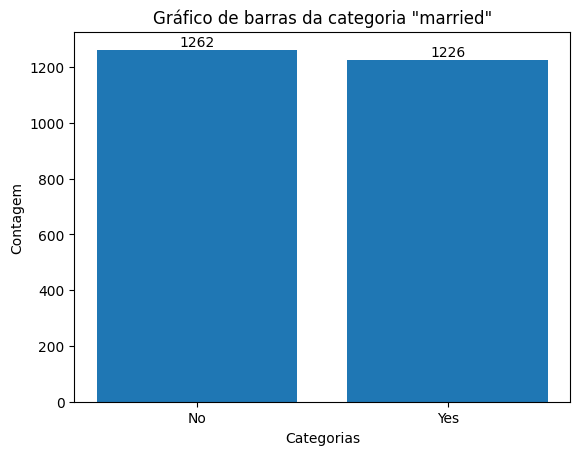

In [8]:
married_counts = df['married'].value_counts()
plt.bar(married_counts.index, married_counts.values)
plt.xlabel('Categorias')
plt.ylabel('Contagem')
plt.title('Gráfico de barras da categoria "married"')
plt.xticks([0, 1])
for index, value in married_counts.items():
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()

Já quando avaliamos a categoria "married", podemos notar que a disposição dos dados é muito mais equilibrada, garantindo uma maior consistência para futuras análises preditivas e machine learning.

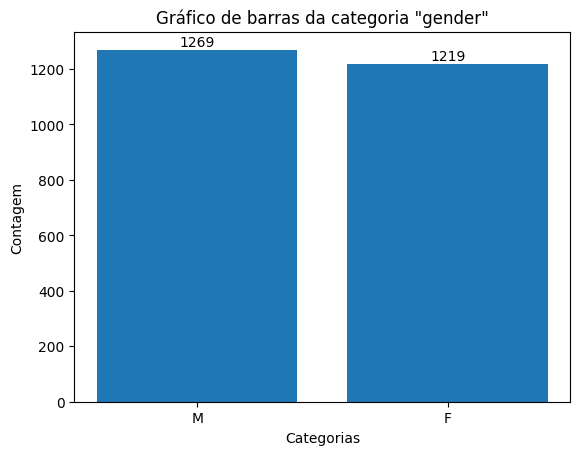

In [9]:
gender_counts = df['gender'].value_counts()
plt.bar(gender_counts.index, gender_counts.values)
plt.xlabel('Categorias')
plt.ylabel('Contagem')
plt.title('Gráfico de barras da categoria "gender"')
plt.xticks([0, 1])
for index, value in gender_counts.items():
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()

Em relação ao gênero dos clientes, também possuímos uma distribuição bem equilibrada.

Agora, vamos dispor os pagamentos mensais para analisar se há alguma inconsistência nos dados:

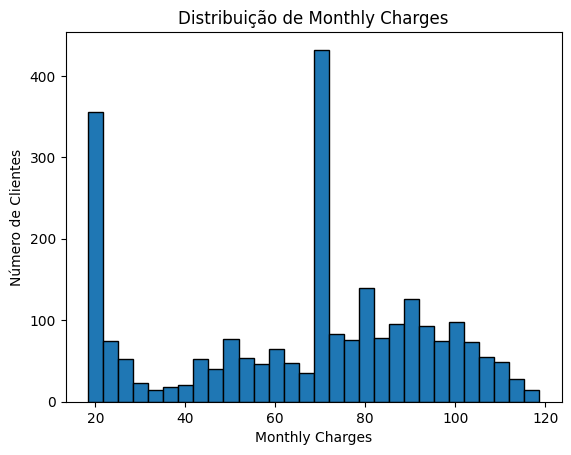

In [10]:
plt.hist(df['monthly_charges'], bins=30, edgecolor='black')
plt.title('Distribuição de Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Número de Clientes')
plt.show()

A disposição dos dados se dá de forma bem equilibrada, justificando os valores próximos nos intervalos interquartis. Podemos notar uma grande quantidade de clientes concentrada entre os valores de 60 e 80 nos pagamentos mensais, ou seja, a maior parte dos pacotes vendidos estão próximos do intervalo de 50% IQR (71,45), garantindo consistência para essa análise.

Vamos então analisar a tendência de permanência dos clientes ao longo dos meses através de um histograma:

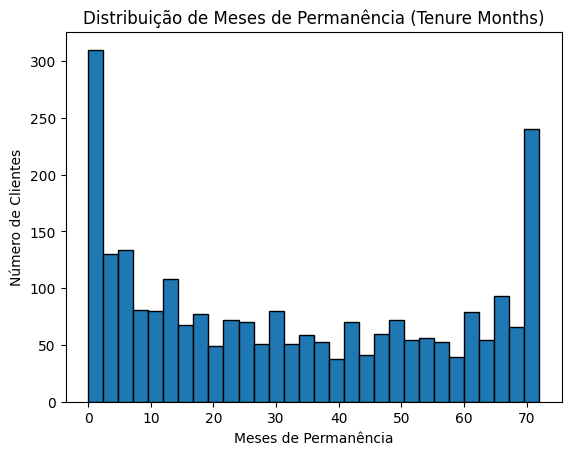

In [11]:
plt.hist(df['tenure_months'], bins=30, edgecolor='black')
plt.title('Distribuição de Meses de Permanência (Tenure Months)')
plt.xlabel('Meses de Permanência')
plt.ylabel('Número de Clientes')
plt.show()

Podemos notar que há outliers nessa análise, consistindo em clientes novos (2 meses ou menos) ou muito antigos(70+ meses). Além disso, podemos inferir que os clientes passam por alguns meses de avaliação dos serviços da empresa e a maior parte dos clientes fidelizados são aqueles que passam dos 70 meses de contrato. Devemos então considerar que os anos iniciais de contrato são cruciais para a fidelização, por isso, iremos remover os dados de clientes muito novos e muito antigos para tornar possível avaliar o que leva ao churn antes do contrato chegar a mais de 70 meses de duração.

# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


Com base nos últimos gráficos, podemos notar que a análise de meses de permanência nos mostrou que há uma grande quantidade de clientes recentes (até 2 meses de contrato) e clientes muito antigos (mais de 70 meses de contrato).
Nesse caso, iremos substituir esses dados pela mediana para prosseguirmos com a análise.

In [12]:
df_novo = df.copy()
Q1 = df_novo['tenure_months'].quantile(0.25)
Q3 = df_novo['tenure_months'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_sem_outliers = df_novo[(df_novo['tenure_months'] >= lower_bound) & (df_novo['tenure_months'] <= upper_bound)]

mediana_sem_outliers = df_sem_outliers['tenure_months'].median()

df_novo.loc[df_novo['tenure_months'] < 3, 'tenure_months'] = mediana_sem_outliers
df_novo.loc[df_novo['tenure_months'] > 69, 'tenure_months'] = mediana_sem_outliers


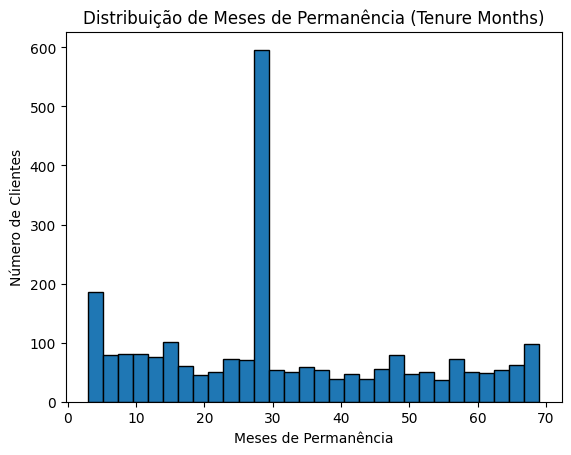

In [13]:
plt.hist(df_novo['tenure_months'], bins=30, edgecolor='black')
plt.title('Distribuição de Meses de Permanência (Tenure Months)')
plt.xlabel('Meses de Permanência')
plt.ylabel('Número de Clientes')
plt.show()

# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.


B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

Com base nas análises anteriores, podemos estabelecer alguns questionamentos em relação ao banco de dados:

*   O churn é maior por pessoas solteiras ou casadas?
*   O churn tem alguma relação com gênero?
*   E com a idade?
*   Podemos correlacionar o churn aos meses de permanência do cliente? Qual o tempo médio para optar pelo churn?
*   Qual a relação entre os valores mensais e o churn?












In [18]:
fig = px.histogram(df_novo, x='churn', color='married', barmode='stack', text_auto=True)

fig.update_layout(title='Relação entre churn e casamento',
                  xaxis_title='Churn',
                  yaxis_title='Contagem',
                  legend_title='Casamento'
                  )

fig.show()

Nesse estudo, podemos ver claramente que o churn é muito maior em pessoas solteiras, condizendo com 408 casos do total de 647 casos de churn. É possível que haja uma correlação positiva entre churn e ser solteiro.

In [19]:
fig = px.histogram(df_novo, x='churn', color='gender', barmode='stack', text_auto=True)

fig.update_layout(title='Relação entre churn e gênero',
                  xaxis_title='Churn',
                  yaxis_title='Contagem',
                  legend_title='Gênero'
                  )

fig.show()

Quando avaliamos o gênero, não há um desequilíbrio muito grande nos casos de churn e não-churn. Possivelmente a correlação é consideravelmente baixa entre essas variáveis.

In [20]:
fig = px.histogram(df_novo, x='churn', color='elderly', barmode='stack', text_auto=True)

fig.update_layout(title='Relação entre churn e idade',
                  xaxis_title='Churn',
                  yaxis_title='Contagem',
                  legend_title='Idosos'
                  )

fig.show()

Aqui podemos notar que, dentre os idosos, temos um churn de 38,8%, enquanto as pessoas mais jovens apresentam churn de 23,3% dentro de seus respectivos grupos. A correlação entre ser considerado idoso e optar pelo churn é possivelmente positiva.

In [26]:
mediana = df.groupby('churn')['tenure_months'].median().reset_index()

fig = px.bar(mediana, x='churn',
             y='tenure_months',
             title='Média de tempo de contrato para o churn',
             text_auto=True)

fig.show()

Podemos observar então que o tempo médio das pessoas queoptam pelo churn é de 10 meses, podendo ser um marco crucial para campanhas de fidelização da empresa.

In [38]:
fig = px.histogram(df, x='monthly_charges', color='churn', barmode='stack',
             title='Churn por Monthly Charges',
             labels={'monthly_charges': 'Monthly Charges', 'count': 'Número de Clientes', 'churn': 'Churn'},
             text_auto=True)

fig.show()

Agora podemos visualizar o churn pelos valores das mensalidades dos planos, nos mostrando que os planos acima do valor 72 tendem a ter maior parte dos churns, o que pode guiar futuras campanhas para clientes que optam por planos mais custosos.